# Individual-Based Simulation of the Progenitor–Neuron System

Agent-level counterpart to the PDE model in `sim_jellyfish_eqn_clean.ipynb`.

Each progenitor and neuron carries a 2D position $(x, y)$ on the jellyfish disk,
stored in polar form $(r, \theta)$ for convenience.

**Rules per time-step $\Delta t$:**

| Event | Process |
|---|---|
| Progenitor birth | Poisson arrivals with spatial rate $b(r) = b_0 \exp(-(r-R)^2/\sigma^2)$; born at uniform random $\theta$ |
| Cell motion | **Cartesian** step: $\Delta x = -v\,\tfrac{x}{r}\,dt + \sqrt{2D\,dt}\;N_x$, $\Delta y = -v\,\tfrac{y}{r}\,dt + \sqrt{2D\,dt}\;N_y$. Converts back to $(r,\theta)$ after each step. Drift is directed radially inward; diffusion is isotropic in physical space. |
| Differentiation | Each progenitor converts to neuron with prob $d\,\Delta t$ |
| Neuron death | Each neuron dies with prob $m(r)\,\Delta t$, where $m(r) = m_0 / |r - 0.95\,r_\text{mouth}|$ |

Reflecting no-flux boundaries are applied to $r$ at $r_\text{mouth}$ and $R$; $\theta$ is unconstrained.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import colors as mcolors
from scipy.stats import gaussian_kde
import seaborn as sns
import tqdm


## Model parameters
Same geometry and rates as the PDE notebook.


In [2]:
params = {
    # Geometry
    'r_mouth': 0.14,   # inner radius (normalized)
    'R':       1.0,    # outer radius
    'sigma':   0.2,    # width of progenitor birth-rate Gaussian

    # Diffusion (same units as PDE: radius²/hour)
    'D_P': 3e-5,
    'D_N': 3e-5,

    # Inward drift (radius/hour)
    'v_P': 0.003,
    'v_N': 0.003,

    # Rates
    'b_0': 3.0,    # progenitor birth rate amplitude  (cells/area/hour)
    'd':   0.03,   # per-capita differentiation rate  (1/hour)
    'm_0': 0.002,  # mortality amplitude               (1/hour * radius)
}


## Rate functions


In [3]:
def birth_rate(r, p):
    """Volumetric progenitor birth rate b(r) [cells / area / hour]."""
    return p['b_0'] * np.exp(-(r - p['R'])**2 / p['sigma']**2)


def mortality_rate(r, p):
    """Per-capita neuron mortality rate m(r) [1/hour]."""
    return p['m_0'] / np.abs(r - 0.95 * p['r_mouth'])


def _reflect(r, r_lo, r_hi):
    """Reflect positions that leave [r_lo, r_hi] back into the domain."""
    # lower boundary
    mask = r < r_lo
    r[mask] = 2 * r_lo - r[mask]
    # upper boundary
    mask = r > r_hi
    r[mask] = 2 * r_hi - r[mask]
    # clamp any remaining outliers (rare double-bounce)
    np.clip(r, r_lo, r_hi, out=r)
    return r


def _sample_birth_positions(n_new, p, rng, n_grid=500):
    """Sample radial positions for n_new progenitors from b(r)*r distribution."""
    r_grid = np.linspace(p['r_mouth'], p['R'], n_grid)
    weights = birth_rate(r_grid, p) * r_grid   # proportional to 2πr b(r) dr
    weights /= weights.sum()
    return rng.choice(r_grid, size=n_new, replace=True, p=weights)


## IBM simulation


In [4]:
def simulate_ibm(params, T_final, dt, snapshot_interval=1.0, seed=42):
    """
    Individual-based simulation of the progenitor–neuron system.

    Each particle has a radial coordinate r.  Motion follows the Itô SDE:
        dr = (D/r - v) dt  +  sqrt(2D) dW
    which is the correct radial projection of 2-D isotropic diffusion + inward
    drift v, with reflecting boundaries at r_mouth and R.

    Birth is a spatial Poisson process with intensity b(r)*2πr dr per hour.
    Differentiation and death are per-capita Poisson processes.

    Parameters
    ----------
    params : dict
    T_final : float          total simulation time (hours)
    dt : float               time step (hours)
    snapshot_interval : float  how often (hours) to save a snapshot
    seed : int

    Returns
    -------
    dict with keys:
        'times'      – snapshot times
        'P_snaps'    – list of progenitor r-arrays at each snapshot
        'N_snaps'    – list of neuron r-arrays at each snapshot
        'P_counts'   – number of progenitors at each snapshot
        'N_counts'   – number of neurons at each snapshot
    """
    rng = np.random.default_rng(seed)

    r_lo = params['r_mouth']
    r_hi = params['R']
    D_P  = params['D_P']
    D_N  = params['D_N']
    v_P  = params['v_P']
    v_N  = params['v_N']
    d    = params['d']

    # ── Pre-compute total birth rate for Poisson sampling ─────────────────
    # Total births per hour = ∫ b(r) 2πr dr  (integral over disk annulus)
    r_grid = np.linspace(r_lo, r_hi, 2000)
    dr_g   = r_grid[1] - r_grid[0]
    total_birth_rate = 2 * np.pi * np.sum(birth_rate(r_grid, params) * r_grid) * dr_g

    # ── Initial conditions: empty domain ──────────────────────────────────
    P = np.empty(0, dtype=float)   # progenitor radial positions
    N = np.empty(0, dtype=float)   # neuron radial positions

    n_steps = int(np.ceil(T_final / dt))
    next_snapshot = 0.0
    snap_times, P_snaps, N_snaps = [], [], []
    P_counts, N_counts = [], []

    sqrt_2DP_dt = np.sqrt(2 * D_P * dt)
    sqrt_2DN_dt = np.sqrt(2 * D_N * dt)

    for step in tqdm.trange(n_steps, desc="IBM"):
        t = step * dt

        # ── Save snapshot ─────────────────────────────────────────────────
        if t >= next_snapshot - 1e-9:
            snap_times.append(t)
            P_snaps.append(P.copy())
            N_snaps.append(N.copy())
            P_counts.append(len(P))
            N_counts.append(len(N))
            next_snapshot += snapshot_interval

        # ── 1. Spontaneous progenitor birth (Poisson) ─────────────────────
        n_new = rng.poisson(total_birth_rate * dt)
        if n_new > 0:
            new_r = _sample_birth_positions(n_new, params, rng)
            P = np.concatenate([P, new_r])

        # ── 2. Progenitor motion: Itô SDE dr = (D_P/r - v_P)dt + noise ───
        if P.size > 0:
            noise = rng.standard_normal(P.size) * sqrt_2DP_dt
            P += (D_P / P - v_P) * dt + noise
            P = _reflect(P, r_lo, r_hi)

        # ── 3. Differentiation: each progenitor → neuron w/ prob d*dt ─────
        if P.size > 0:
            diff_mask = rng.random(P.size) < d * dt
            new_neurons = P[diff_mask]
            P = P[~diff_mask]
            N = np.concatenate([N, new_neurons])

        # ── 4. Neuron motion: Itô SDE dr = (D_N/r - v_N)dt + noise ───────
        if N.size > 0:
            noise = rng.standard_normal(N.size) * sqrt_2DN_dt
            N += (D_N / N - v_N) * dt + noise
            N = _reflect(N, r_lo, r_hi)

        # ── 5. Neuron death: each neuron dies w/ prob m(r)*dt ─────────────
        if N.size > 0:
            m = mortality_rate(N, params)
            survive = rng.random(N.size) >= m * dt
            N = N[survive]

    # final snapshot
    snap_times.append(n_steps * dt)
    P_snaps.append(P.copy())
    N_snaps.append(N.copy())
    P_counts.append(len(P))
    N_counts.append(len(N))

    return {
        'times':    np.array(snap_times),
        'P_snaps':  P_snaps,
        'N_snaps':  N_snaps,
        'P_counts': np.array(P_counts),
        'N_counts': np.array(N_counts),
    }


## Run simulation


In [5]:
T_final = 120.0   # hours
dt      = 0.05    # time step (hours) — larger than PDE is fine for IBM

result = simulate_ibm(params, T_final, dt, snapshot_interval=1.0, seed=0)

times    = result['times']
P_snaps  = result['P_snaps']
N_snaps  = result['N_snaps']
P_counts = result['P_counts']
N_counts = result['N_counts']

print(f"Snapshots: {len(times)}")
print(f"Final progenitor count : {P_counts[-1]}")
print(f"Final neuron count     : {N_counts[-1]}")


IBM: 100%|██████████| 2400/2400 [00:00<00:00, 21668.85it/s]

Snapshots: 121
Final progenitor count : 109
Final neuron count     : 212


## Population counts over time


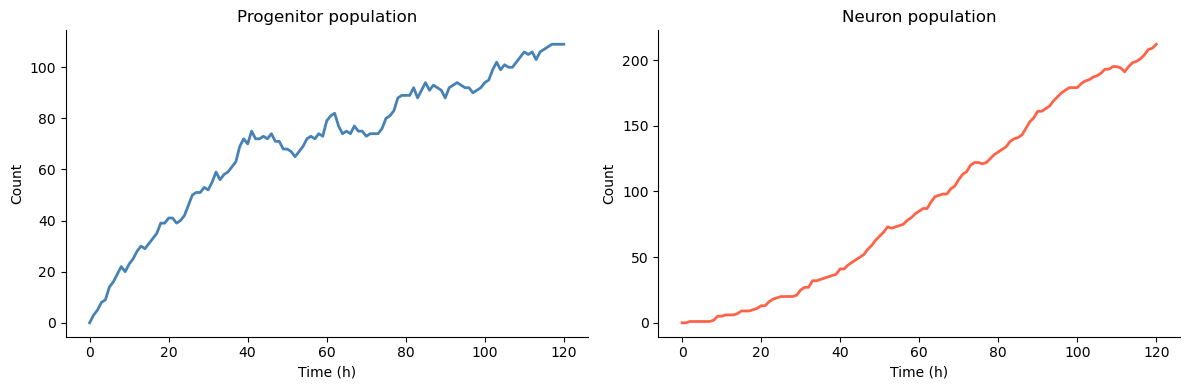

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(times, P_counts, color='steelblue', lw=2)
axes[0].set_xlabel('Time (h)')
axes[0].set_ylabel('Count')
axes[0].set_title('Progenitor population')

axes[1].plot(times, N_counts, color='tomato', lw=2)
axes[1].set_xlabel('Time (h)')
axes[1].set_ylabel('Count')
axes[1].set_title('Neuron population')

sns.despine()
plt.tight_layout()
plt.show()


## Circular heatmap snapshots
Convert particle positions to 2-D density via KDE evaluated on the disk, then
visualise exactly as in `sim_jellyfish_eqn_clean.ipynb`.


/var/folders/87/w43tb79n67n08xyspfl0n8390zhhg9/T/ipykernel_2284/3264063632.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


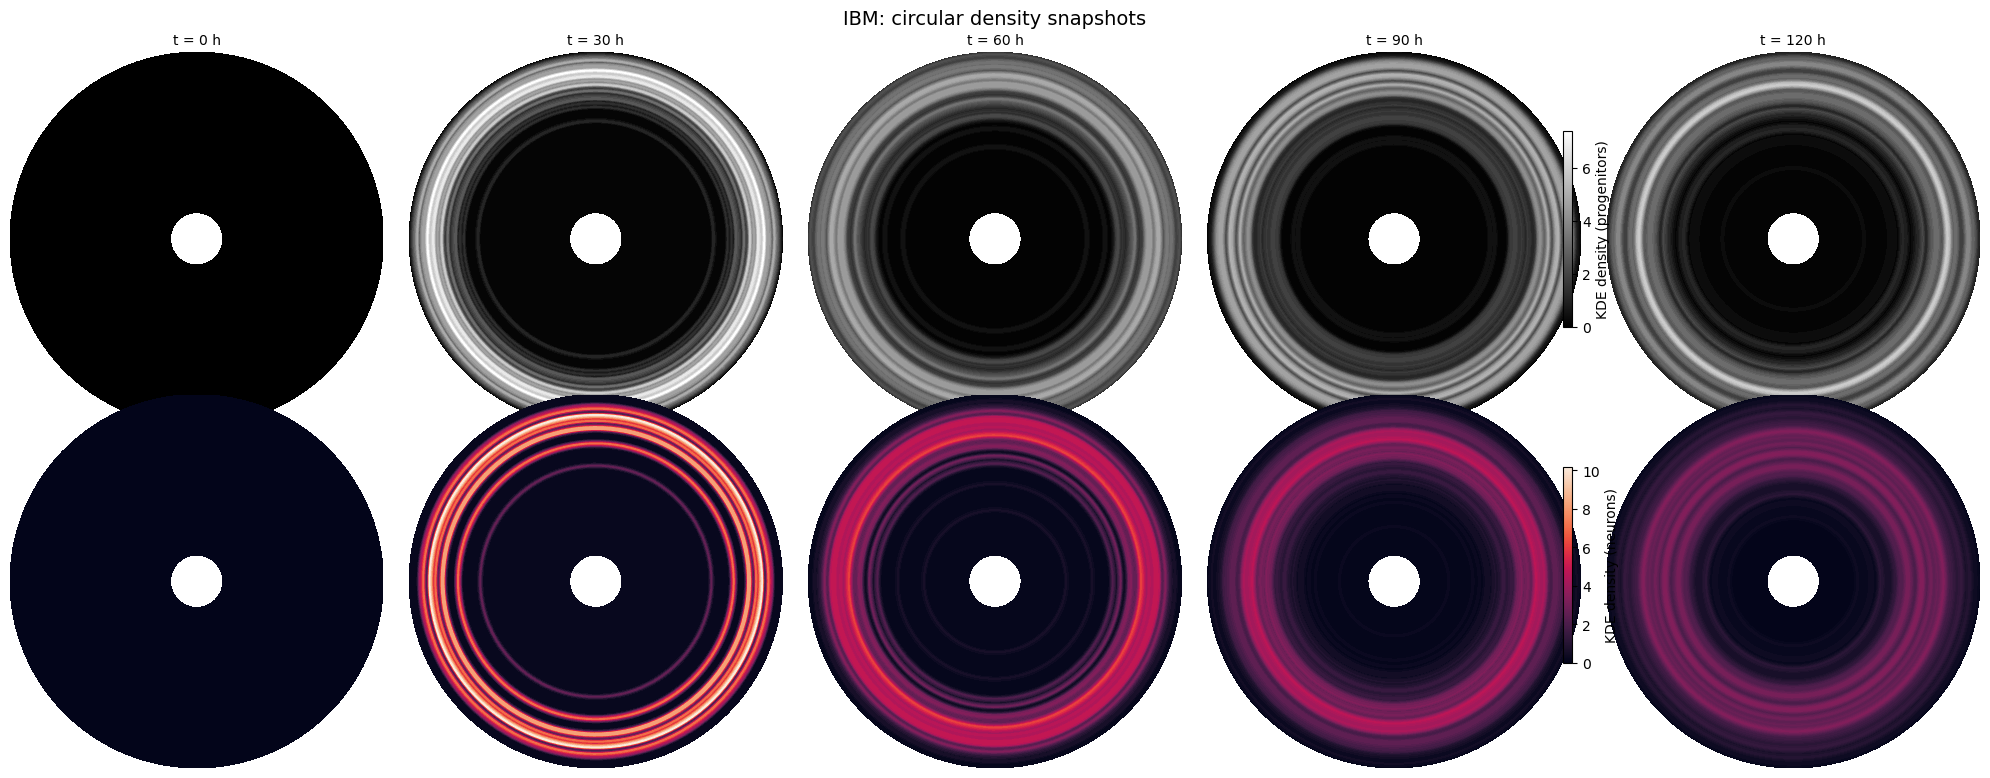

In [7]:
def radial_kde_on_disk(r_particles, params, n_theta=120, n_r=80, bw=0.08):
    """
    Convert 1-D radial particle positions to a 2-D density on the disk by
    assuming rotational symmetry and using a radial KDE.

    Returns x_vals, y_vals (meshgrid on disk) and density (same shape).
    """
    r_lo = params['r_mouth']
    r_hi = params['R']
    r_grid = np.linspace(r_lo, r_hi, n_r)

    if len(r_particles) < 2:
        density_1d = np.zeros(n_r)
    else:
        kde = gaussian_kde(r_particles, bw_method=bw)
        density_1d = kde(r_grid)
        density_1d = np.maximum(density_1d, 0)

    theta_grid = np.linspace(0, 2 * np.pi, n_theta)
    # x_vals[i, j] = r_grid[j] * cos(theta_grid[i])
    x_vals = r_grid * np.cos(theta_grid[:, None])   # (n_theta, n_r)
    y_vals = r_grid * np.sin(theta_grid[:, None])   # (n_theta, n_r)
    density = np.tile(density_1d, (n_theta, 1))     # (n_theta, n_r)

    return x_vals, y_vals, density


# ── Choose snapshot indices to display ─────────────────────────────────────
snap_indices = [0,
                len(times) // 4,
                len(times) // 2,
                3 * len(times) // 4,
                -1]

cmap_P = 'gist_gray'
cmap_N = sns.color_palette('rocket', as_cmap=True)

# Global colour limits across all shown snapshots
P_densities = []
N_densities = []
for si in snap_indices:
    _, _, dp = radial_kde_on_disk(P_snaps[si], params)
    _, _, dn = radial_kde_on_disk(N_snaps[si], params)
    P_densities.append(dp)
    N_densities.append(dn)

norm_P = mcolors.Normalize(vmin=0, vmax=max(d.max() for d in P_densities))
norm_N = mcolors.Normalize(vmin=0, vmax=max(d.max() for d in N_densities))

fig, axs = plt.subplots(2, len(snap_indices), figsize=(4 * len(snap_indices), 8))
fig.suptitle("IBM: circular density snapshots", fontsize=14)

for col, (si, dp, dn) in enumerate(zip(snap_indices, P_densities, N_densities)):
    t_val = times[si]
    x_vals, y_vals, _ = radial_kde_on_disk(P_snaps[si], params)

    axs[0, col].contourf(x_vals, y_vals, dp, levels=25, cmap=cmap_P, norm=norm_P)
    axs[0, col].set_aspect('equal')
    axs[0, col].set_axis_off()
    axs[0, col].set_title(f't = {t_val:.0f} h', fontsize=10)
    if col == 0:
        axs[0, col].set_ylabel('Progenitors', fontsize=11)

    axs[1, col].contourf(x_vals, y_vals, dn, levels=25, cmap=cmap_N, norm=norm_N)
    axs[1, col].set_aspect('equal')
    axs[1, col].set_axis_off()
    if col == 0:
        axs[1, col].set_ylabel('Neurons', fontsize=11)

# Shared colorbars
fig.colorbar(plt.cm.ScalarMappable(norm=norm_P, cmap=cmap_P),
             ax=axs[0, :], shrink=0.7, label='KDE density (progenitors)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm_N, cmap=cmap_N),
             ax=axs[1, :], shrink=0.7, label='KDE density (neurons)')

plt.tight_layout()
plt.show()


## GIF animation — circular heatmaps


In [8]:
gif_path = "../results/ibm_circular_density.gif"
fps      = 15
n_frames = len(times)  # one frame per snapshot hour

# Pre-compute KDE densities for all frames (avoids recomputing inside update)
print("Pre-computing KDE for all frames …")
all_P_dens = []
all_N_dens = []
xy_ref = None
for i in tqdm.trange(n_frames, desc="KDE"):
    x_v, y_v, dp = radial_kde_on_disk(P_snaps[i], params)
    _,   _,   dn = radial_kde_on_disk(N_snaps[i], params)
    all_P_dens.append(dp)
    all_N_dens.append(dn)
    if xy_ref is None:
        xy_ref = (x_v, y_v)

x_vals, y_vals = xy_ref

# Global colour limits
norm_P = mcolors.Normalize(vmin=0, vmax=max(d.max() for d in all_P_dens))
norm_N = mcolors.Normalize(vmin=0, vmax=max(d.max() for d in all_N_dens))

cmap_P = 'gist_gray'
cmap_N = sns.color_palette('rocket', as_cmap=True)

fig, (axP, axN) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("IBM: progenitor & neuron density", fontsize=13)
fig.colorbar(plt.cm.ScalarMappable(norm=norm_P, cmap=cmap_P), ax=axP, label="Progenitor KDE")
fig.colorbar(plt.cm.ScalarMappable(norm=norm_N, cmap=cmap_N), ax=axN, label="Neuron KDE")

def update(frame_idx):
    axP.clear()
    axN.clear()

    axP.contourf(x_vals, y_vals, all_P_dens[frame_idx], levels=25, cmap=cmap_P, norm=norm_P)
    axN.contourf(x_vals, y_vals, all_N_dens[frame_idx], levels=25, cmap=cmap_N, norm=norm_N)

    t_val = times[frame_idx]
    for ax, title in ((axP, f"Progenitors  t={t_val:.0f} h  (n={P_counts[frame_idx]})"),
                      (axN, f"Neurons      t={t_val:.0f} h  (n={N_counts[frame_idx]})")):
        ax.set_aspect("equal")
        ax.set_axis_off()
        ax.set_title(title, fontsize=11)

ani = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)
ani.save(gif_path, writer="pillow", fps=fps)
plt.close(fig)
print(f"Saved: {gif_path}")


Pre-computing KDE for all frames …


KDE: 100%|██████████| 121/121 [00:00<00:00, 705.01it/s]


Saved: ../results/ibm_circular_density.gif


## Individual cell tracking

Re-run the IBM tracking every cell's full $(r, \theta)$ trajectory.
Each step moves cells in Cartesian $(x, y)$, so $\theta$ genuinely diffuses — tracks
wander around the disk rather than staying at a fixed angle.
Progenitor segments are drawn in **orange**; the track switches to **teal** at the moment of differentiation.


In [9]:
def simulate_ibm_tracked(params, T_final, dt, snapshot_interval=1.0, seed=42):
    """
    IBM with per-cell identity tracking.

    Motion is implemented in Cartesian (x, y) coordinates so that diffusion is
    isotropic in physical space — no Ito correction needed.  The inward radial
    drift is applied in Cartesian as well (pointing toward the origin), and the
    result is converted back to polar (r, theta) after each step.

    Returns
    -------
    dict with keys
        'times'       – snapshot times array
        'snaps'       – list of dicts {p_ids, p_r, p_theta, n_ids, n_r, n_theta}
        'birth_times' – {cell_id: time}
        'diff_times'  – {cell_id: time}  (only for cells that differentiated)
        'death_times' – {cell_id: time}  (only for cells that died)
    """
    rng  = np.random.default_rng(seed)
    r_lo = params['r_mouth'];  r_hi = params['R']
    D_P  = params['D_P'];      D_N  = params['D_N']
    v_P  = params['v_P'];      v_N  = params['v_N']
    d    = params['d']

    # total progenitor birth rate (Poisson intensity)
    r_g  = np.linspace(r_lo, r_hi, 2000)
    dr_g = r_g[1] - r_g[0]
    total_birth_rate = 2*np.pi * np.sum(birth_rate(r_g, params) * r_g) * dr_g

    # cell state arrays  (polar coordinates)
    p_ids   = np.empty(0, dtype=np.int64)
    p_r     = np.empty(0, dtype=float)
    p_theta = np.empty(0, dtype=float)
    n_ids   = np.empty(0, dtype=np.int64)
    n_r     = np.empty(0, dtype=float)
    n_theta = np.empty(0, dtype=float)

    next_id      = 0
    birth_times  = {}
    diff_times   = {}
    death_times  = {}

    snap_times = []
    snaps      = []
    next_snap  = 0.0

    # std-dev of each Cartesian displacement per step
    sig_P = np.sqrt(2 * D_P * dt)
    sig_N = np.sqrt(2 * D_N * dt)

    n_steps = int(np.ceil(T_final / dt))

    for step in tqdm.trange(n_steps, desc="IBM (tracked)"):
        t = step * dt

        # ── snapshot ─────────────────────────────────────────────────────
        if t >= next_snap - 1e-9:
            snap_times.append(t)
            snaps.append(dict(p_ids=p_ids.copy(), p_r=p_r.copy(), p_theta=p_theta.copy(),
                              n_ids=n_ids.copy(), n_r=n_r.copy(), n_theta=n_theta.copy()))
            next_snap += snapshot_interval

        # ── 1. birth ─────────────────────────────────────────────────────
        n_new = rng.poisson(total_birth_rate * dt)
        if n_new:
            new_r     = _sample_birth_positions(n_new, params, rng)
            new_theta = rng.uniform(0, 2*np.pi, n_new)
            new_ids   = np.arange(next_id, next_id + n_new, dtype=np.int64)
            next_id  += n_new
            p_ids   = np.concatenate([p_ids,   new_ids])
            p_r     = np.concatenate([p_r,     new_r])
            p_theta = np.concatenate([p_theta, new_theta])
            for cid in new_ids.tolist():
                birth_times[cid] = t

        # ── 2. progenitor motion — step in Cartesian, convert back ───────
        if p_r.size:
            # current Cartesian position
            px = p_r * np.cos(p_theta)
            py = p_r * np.sin(p_theta)
            # inward radial drift in Cartesian: -v * (x/r, y/r)
            px -= v_P * np.cos(p_theta) * dt
            py -= v_P * np.sin(p_theta) * dt
            # isotropic diffusion: independent Gaussian increments in x and y
            px += rng.standard_normal(p_r.size) * sig_P
            py += rng.standard_normal(p_r.size) * sig_P
            # back to polar
            p_r     = np.sqrt(px**2 + py**2)
            p_theta = np.arctan2(py, px)
            # reflect radial boundary (theta is periodic — no constraint)
            p_r = _reflect(p_r, r_lo, r_hi)

        # ── 3. differentiation ───────────────────────────────────────────
        if p_r.size:
            mask = rng.random(p_r.size) < d * dt
            if mask.any():
                n_ids   = np.concatenate([n_ids,   p_ids[mask]])
                n_r     = np.concatenate([n_r,     p_r[mask]])
                n_theta = np.concatenate([n_theta, p_theta[mask]])
                for cid in p_ids[mask].tolist():
                    diff_times[cid] = t
                p_ids   = p_ids[~mask]
                p_r     = p_r[~mask]
                p_theta = p_theta[~mask]

        # ── 4. neuron motion — step in Cartesian, convert back ────────────
        if n_r.size:
            nx = n_r * np.cos(n_theta)
            ny = n_r * np.sin(n_theta)
            nx -= v_N * np.cos(n_theta) * dt
            ny -= v_N * np.sin(n_theta) * dt
            nx += rng.standard_normal(n_r.size) * sig_N
            ny += rng.standard_normal(n_r.size) * sig_N
            n_r     = np.sqrt(nx**2 + ny**2)
            n_theta = np.arctan2(ny, nx)
            n_r     = _reflect(n_r, r_lo, r_hi)

        # ── 5. neuron death ──────────────────────────────────────────────
        if n_r.size:
            m       = mortality_rate(n_r, params)
            survive = rng.random(n_r.size) >= m * dt
            for cid in n_ids[~survive].tolist():
                death_times[cid] = t
            n_ids   = n_ids[survive]
            n_r     = n_r[survive]
            n_theta = n_theta[survive]

    # final snapshot
    snap_times.append(n_steps * dt)
    snaps.append(dict(p_ids=p_ids.copy(), p_r=p_r.copy(), p_theta=p_theta.copy(),
                      n_ids=n_ids.copy(), n_r=n_r.copy(), n_theta=n_theta.copy()))

    return dict(times=np.array(snap_times), snaps=snaps,
                birth_times=birth_times, diff_times=diff_times, death_times=death_times)


# ── Reconstruct per-cell track histories from snapshot data ────────────────
def reconstruct_tracks(tracked):
    """
    Returns a list of track dicts, one per cell:
        id, times, r, theta, is_neuron  (all arrays aligned by snapshot)
    theta is the actual angle at each snapshot (not fixed at birth).
    """
    cell_data = {}   # id -> {'times': [], 'r': [], 'theta': [], 'is_neuron': []}

    for snap, t in zip(tracked['snaps'], tracked['times']):
        for cid, r, th in zip(snap['p_ids'].tolist(), snap['p_r'].tolist(), snap['p_theta'].tolist()):
            cd = cell_data.setdefault(cid, {'times': [], 'r': [], 'theta': [], 'is_neuron': []})
            cd['times'].append(t);  cd['r'].append(r)
            cd['theta'].append(th); cd['is_neuron'].append(False)
        for cid, r, th in zip(snap['n_ids'].tolist(), snap['n_r'].tolist(), snap['n_theta'].tolist()):
            cd = cell_data.setdefault(cid, {'times': [], 'r': [], 'theta': [], 'is_neuron': []})
            cd['times'].append(t);  cd['r'].append(r)
            cd['theta'].append(th); cd['is_neuron'].append(True)

    tracks = []
    for cid, cd in cell_data.items():
        tracks.append(dict(
            id        = cid,
            times     = np.array(cd['times']),
            r         = np.array(cd['r']),
            theta     = np.array(cd['theta']),   # evolves each snapshot
            is_neuron = np.array(cd['is_neuron']),
        ))
    return tracks


In [10]:
tracked = simulate_ibm_tracked(params, T_final=120.0, dt=0.05,
                               snapshot_interval=1.0, seed=0)

tracks = reconstruct_tracks(tracked)
print(f"Total cells born : {len(tracks)}")
print(f"Snapshots        : {len(tracked['times'])}")
print(f"Cells that differentiated : {len(tracked['diff_times'])}")
print(f"Cells that died           : {len(tracked['death_times'])}")


IBM (tracked): 100%|██████████| 2400/2400 [00:00<00:00, 13889.04it/s]

Total cells born : 365
Snapshots        : 121
Cells that differentiated : 245
Cells that died           : 41


### Snapshot scatter plots — cells on the disk


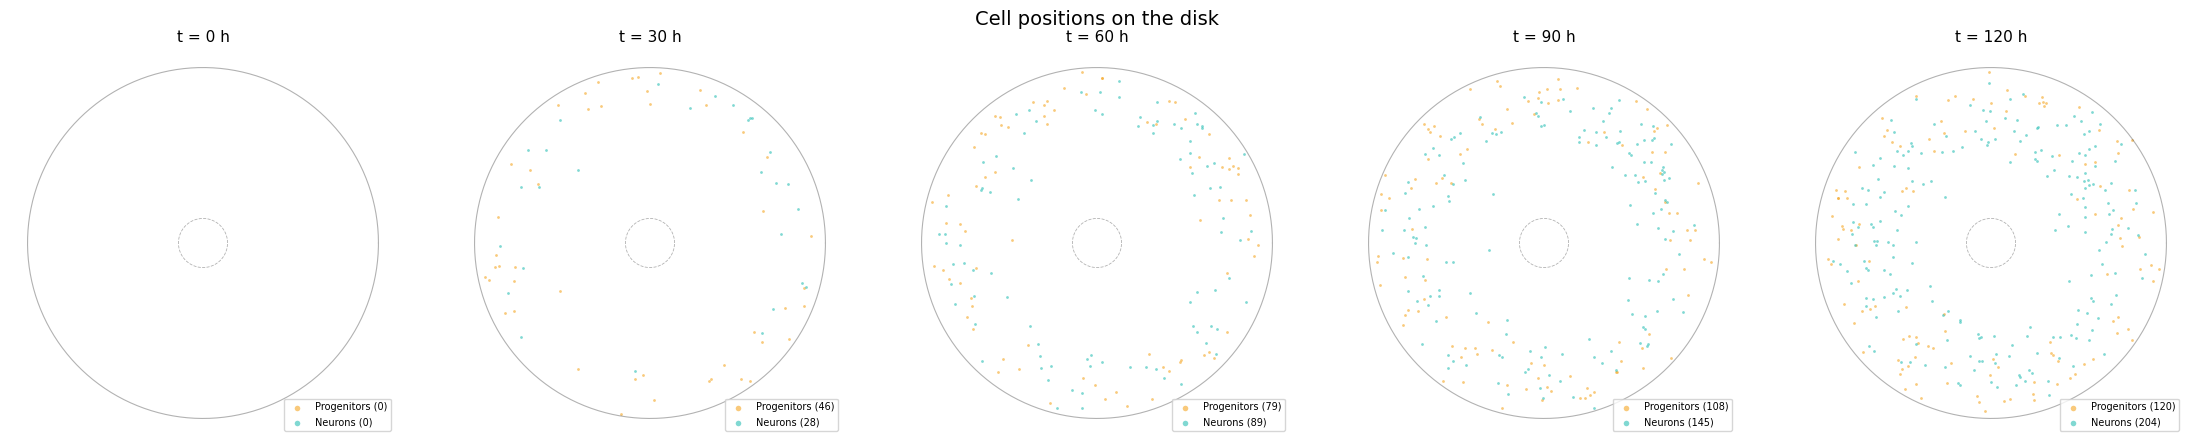

In [11]:
COLOR_P = '#F5A623'   # orange  – progenitors
COLOR_N = '#2BBFB5'  # teal    – neurons

snap_indices = [0, len(tracked['times'])//4, len(tracked['times'])//2,
                3*len(tracked['times'])//4, -1]

fig, axs = plt.subplots(1, len(snap_indices), figsize=(4.5 * len(snap_indices), 4.5))
fig.suptitle("Cell positions on the disk", fontsize=14)

# draw a faint ring for the jellyfish boundary
theta_ring = np.linspace(0, 2*np.pi, 300)
for ax in axs:
    ax.plot(np.cos(theta_ring), np.sin(theta_ring), 'k-', lw=0.8, alpha=0.3)
    ax.plot(params['r_mouth']*np.cos(theta_ring),
            params['r_mouth']*np.sin(theta_ring), 'k--', lw=0.6, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_axis_off()

for ax, si in zip(axs, snap_indices):
    snap = tracked['snaps'][si]
    t    = tracked['times'][si]

    # progenitors
    px = snap['p_r'] * np.cos(snap['p_theta'])
    py = snap['p_r'] * np.sin(snap['p_theta'])
    ax.scatter(px, py, s=4, color=COLOR_P, alpha=0.6, linewidths=0,
               label=f'Progenitors ({len(snap["p_ids"])})')

    # neurons
    nx = snap['n_r'] * np.cos(snap['n_theta'])
    ny = snap['n_r'] * np.sin(snap['n_theta'])
    ax.scatter(nx, ny, s=4, color=COLOR_N, alpha=0.6, linewidths=0,
               label=f'Neurons ({len(snap["n_ids"])})')

    ax.set_title(f't = {t:.0f} h', fontsize=11)
    ax.legend(fontsize=7, loc='lower right', markerscale=2)

plt.tight_layout()
plt.show()


### Individual cell trajectories
Each line is one cell's path on the disk.  
**Orange** segments = progenitor phase. **Teal** segments = neuron phase.  
The colour switches at the moment of differentiation.


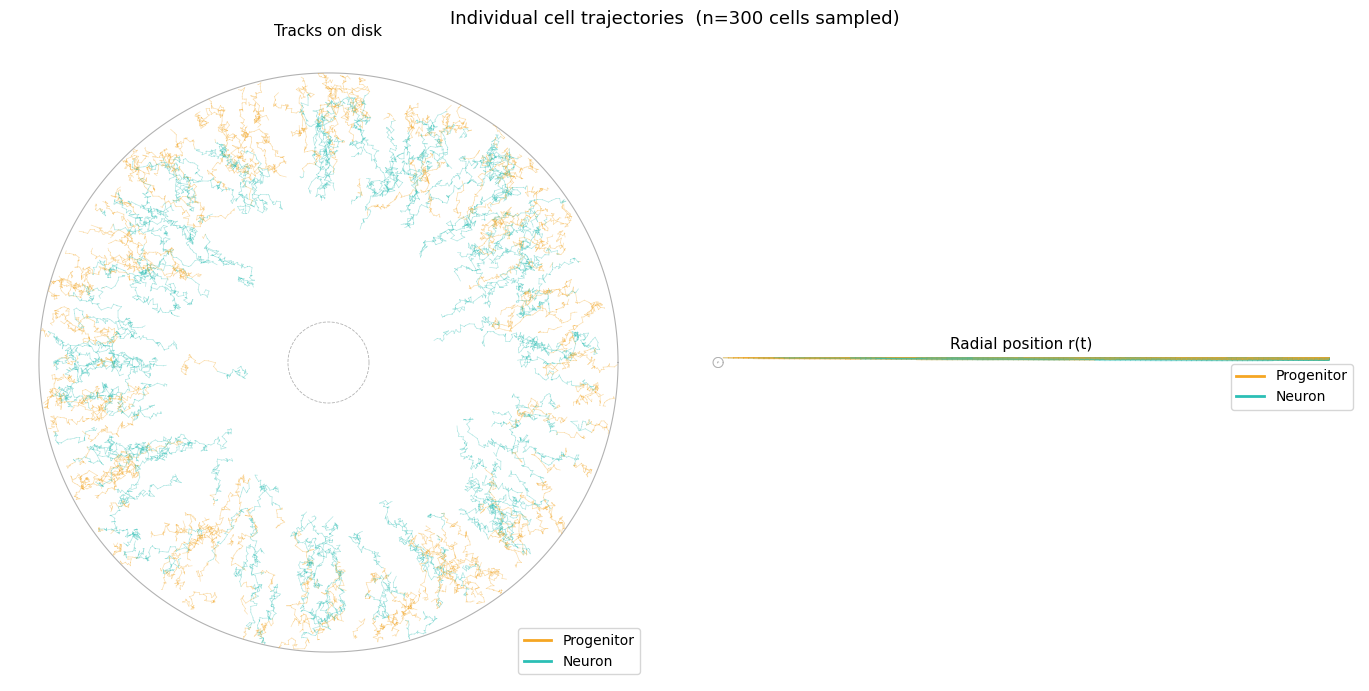

In [12]:
rng_vis = np.random.default_rng(1)

# Keep a random subsample of cells that lived long enough to be interesting
min_snapshots = 5
long_tracks = [tr for tr in tracks if len(tr['times']) >= min_snapshots]
n_show = min(300, len(long_tracks))
shown  = [long_tracks[i] for i in rng_vis.choice(len(long_tracks), n_show, replace=False)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(f"Individual cell trajectories  (n={n_show} cells sampled)", fontsize=13)

for ax in axes:
    ax.plot(np.cos(theta_ring), np.sin(theta_ring), 'k-', lw=0.8, alpha=0.3)
    ax.plot(params['r_mouth']*np.cos(theta_ring),
            params['r_mouth']*np.sin(theta_ring), 'k--', lw=0.6, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_axis_off()

axes[0].set_title("Tracks on disk", fontsize=11)
axes[1].set_title("Radial position r(t)", fontsize=11)

for tr in shown:
    # theta is now a per-snapshot array (cells genuinely diffuse angularly)
    x     = tr['r'] * np.cos(tr['theta'])
    y     = tr['r'] * np.sin(tr['theta'])
    t_arr = tr['times']
    is_n  = tr['is_neuron']

    # draw segment-by-segment, switching colour at differentiation
    for k in range(len(t_arr) - 1):
        col = COLOR_N if is_n[k] else COLOR_P
        axes[0].plot(x[k:k+2],     y[k:k+2],     color=col, lw=0.5, alpha=0.35)
        axes[1].plot(t_arr[k:k+2], tr['r'][k:k+2], color=col, lw=0.5, alpha=0.35)

# legend proxies
from matplotlib.lines import Line2D
axes[0].legend(handles=[
    Line2D([0],[0], color=COLOR_P, lw=2, label='Progenitor'),
    Line2D([0],[0], color=COLOR_N, lw=2, label='Neuron'),
], fontsize=10, loc='lower right')
axes[1].set_xlabel("Time (h)", fontsize=11)
axes[1].set_ylabel("Radius (normalised)", fontsize=11)
axes[1].legend(handles=[
    Line2D([0],[0], color=COLOR_P, lw=2, label='Progenitor'),
    Line2D([0],[0], color=COLOR_N, lw=2, label='Neuron'),
], fontsize=10)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


### GIF — animated scatter with short trails
Each dot is one cell; a short trail (last `trail_len` snapshots) follows it.
Orange = progenitor, teal = neuron. The colour reflects the cell's state **at that moment**.


In [15]:
from matplotlib.collections import LineCollection

gif_tracks_path = "../results/ibm_cell_tracks.gif"
fps_tracks = 12

# ── Colour scheme ────────────────────────────────────────────────────────────
GIF_BG    = 'black'
GIF_COL_P = '#D0D0D0'   # light gray  – progenitors
GIF_COL_N = '#39FF14'   # neon green  – neurons (GFP)
GIF_RING  = '#3A3A3A'   # dim ring    – boundary

n_snaps = len(tracked['times'])

# ── Build snap-index lookup: frame -> {cid: (r, theta, is_neuron)} ───────────
print("Building snapshot lookup …")
snap_lookup = []
for snap in tracked['snaps']:
    d = {}
    for cid, r, th in zip(snap['p_ids'].tolist(), snap['p_r'].tolist(), snap['p_theta'].tolist()):
        d[cid] = (r, th, False)
    for cid, r, th in zip(snap['n_ids'].tolist(), snap['n_r'].tolist(), snap['n_theta'].tolist()):
        d[cid] = (r, th, True)
    snap_lookup.append(d)

# ── Fast per-cell full-history lookup ────────────────────────────────────────
track_map = {tr['id']: tr for tr in tracks}

# ── Figure setup ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3), facecolor=GIF_BG)
ax.set_facecolor(GIF_BG)
ax.set_xlim(-1.05, 1.05);  ax.set_ylim(-1.05, 1.05)
ax.set_aspect('equal');     ax.set_axis_off()
ax.plot(np.cos(theta_ring), np.sin(theta_ring),
        color=GIF_RING, lw=0.8)
ax.plot(params['r_mouth']*np.cos(theta_ring),
        params['r_mouth']*np.sin(theta_ring),
        color=GIF_RING, lw=0.6, ls='--')
title_text = ax.set_title("", fontsize=16, color='white', pad=8)

from matplotlib.lines import Line2D
ax.legend(
    handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor=GIF_COL_P,
               markersize=8, label='Progenitor'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor=GIF_COL_N,
               markersize=8, label='Neuron'),
    ],
    fontsize=10, loc='lower right',
    facecolor='#111111', labelcolor='white', edgecolor='#444444',
)

# Ghost LineCollections (one per cell type) — reused each frame
ghost_lc_P = LineCollection([], colors=GIF_COL_P, linewidths=0.5, alpha=0.18, zorder=1)
ghost_lc_N = LineCollection([], colors=GIF_COL_N, linewidths=0.5, alpha=0.18, zorder=1)
ax.add_collection(ghost_lc_P)
ax.add_collection(ghost_lc_N)

# Current-position scatter
scat_P = ax.scatter([], [], s=8, color=GIF_COL_P, alpha=0.95, linewidths=0, zorder=3)
scat_N = ax.scatter([], [], s=8, color=GIF_COL_N, alpha=0.95, linewidths=0, zorder=3)

def update_tracks(frame):
    cur   = snap_lookup[frame]
    t_val = tracked['times'][frame]

    # ── Ghost: full past path for each alive cell, as a LineCollection ───
    segs_P, segs_N = [], []
    for cid, (r_cur, th_cur, is_n_cur) in cur.items():
        tr = track_map.get(cid)
        if tr is None:
            continue
        mask = tr['times'] <= t_val + 1e-9
        r_g  = tr['r'][mask];  th_g = tr['theta'][mask]
        if len(r_g) < 2:
            continue
        pts = np.stack([r_g * np.cos(th_g),
                        r_g * np.sin(th_g)], axis=1)   # (n, 2)
        if is_n_cur:
            segs_N.append(pts)
        else:
            segs_P.append(pts)

    ghost_lc_P.set_segments(segs_P)
    ghost_lc_N.set_segments(segs_N)

    # ── Current dot positions ─────────────────────────────────────────────
    px, py, nx, ny = [], [], [], []
    for cid, (r, th, is_n) in cur.items():
        x, y = r*np.cos(th), r*np.sin(th)
        if is_n:
            nx.append(x); ny.append(y)
        else:
            px.append(x); py.append(y)
    scat_P.set_offsets(np.c_[px, py] if px else np.empty((0, 2)))
    scat_N.set_offsets(np.c_[nx, ny] if nx else np.empty((0, 2)))

    n_P = sum(1 for v in cur.values() if not v[2])
    n_N = sum(1 for v in cur.values() if     v[2])
    title_text.set_text(f"t = {t_val:.0f} h   |   P = {n_P}   N = {n_N}")

    return [ghost_lc_P, ghost_lc_N, scat_P, scat_N, title_text]


ani_tracks = FuncAnimation(fig, update_tracks, frames=n_snaps,
                           interval=1000 / fps_tracks, blit=False)
ani_tracks.save(gif_tracks_path, writer="pillow", fps=fps_tracks)
plt.close(fig)
print(f"Saved: {gif_tracks_path}")


Building snapshot lookup …
Saved: ../results/ibm_cell_tracks.gif
